In [31]:
import pandas as pd
import numpy as np
import os
import sys
sys.path.append('./shared/')
import prospector_utils

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MultipleLocator, ScalarFormatter
import seaborn as sns

from tqdm import tqdm
from astropy import coordinates as coords
from astropy import units as u

from sedpy.observate import load_filters
from prospect.utils.obsutils import fix_obs
from prospect.models.templates import TemplateLibrary, describe
from prospect.models import SpecModel, priors
from prospect.models.sedmodel import SedModel
from prospect.sources import CSPSpecBasis
from prospect.fitting import lnprobfn, fit_model
from prospect.plotting import corner
from prospect.plotting.utils import best_sample, sample_posterior
from prospect.plotting.sfh import parametric_sfr, parametric_mwa
from prospect.io import write_results as writer
from prospect.io import read_results as reader
from prospect.plotting.corner import quantile

In [4]:
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
})

sns.set_style('ticks', {
    'font.family': ['cm'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.bottom': True,
    'xtick.top': False,
    'ytick.left': True,
    'ytick.right': False,
})

palette = sns.color_palette('tab20b')

In [5]:
def build_obs(obj_id, redshift, filter_set, maggies):

    # filters = observate.load_filters(filter_set)

    # array of effective wavelengths for each of the filters, useful for plotting
    phot_wave = np.array([f.wave_effective for f in filter_set])

    obs = dict(
        obj_id=obj_id,
        clump_id=1,
        peak_id=1,
        wavelength=None, 
        spectrum=None, 
        unc=None, 
        maggies=maggies, 
        maggies_unc=maggies*0.1,
        redshift=redshift,
        redshift_err=0.0,
        phot_mask=np.isfinite(np.squeeze(maggies)),
        filters=filter_set,
        phot_wave=phot_wave
    )
    
    # This function ensures all required keys are present in the obs dictionary,
    # adding default values if necessary
    obs = fix_obs(obs)

    return obs

## Plot SED-fit results and compare to simulated/true values

In [6]:
objid = 43153662431750562
clump_id = 3
peak_id = 1

hfile = './sed_fits/sed_fit_{}_{}_{}.h5'.format(objid, clump_id, peak_id)
result, obs, model = reader.results_from(hfile, dangerous=False)

In [25]:
# read in the true values, but only for those clumps which are detected
mag_cols_true = ['ABmag_sim_clump_{}'.format(band) for band in 'UGRIZY'] # true, simulated clump mags
cols_true = [
    'HSCobjid', 'band', 'clump_id', 'detection_id', 'peak_id', 'peak_detection_id', 
    'CLAUDS_field', 'labels', 'SDSS_redshift', 'SDSS_redshift_error', 'is_specz', 
    'gal_mass', 'gal_z', 'peak_mass', 'peak_tage', 'peak_tau', 'peak_logzsol', 'peak_dust1', 'peak_dust2'
] + mag_cols_true # true, simulated clump mags

df_sim_true = (pd
    .read_parquet('./data/test_data.gzip', engine='pyarrow')
    [cols_true]
    .assign(peak_zred = lambda _df: _df.SDSS_redshift)
)

In [ ]:
logify_labels = ['mass', 'tage', 'tau']
fit_result_dict = prospector_utils.collect_results(result, bands='UGRIZY', logify=logify_labels, alpha=0.05)
_df = (pd
    .DataFrame.from_dict([fit_result_dict])
    # change total formed stellar mass estimates to surviving stellar mass estimates
    .rename(columns={
        'mass_MAP': 'mass_formed_MAP',
        'mass_cr_lower': 'mass_formed_cr_lower', 
        'mass_cr_upper': 'mass_formed_cr_upper', 
        'mass_median': 'mass_formed_median',
        'mass_se_lower': 'mass_formed_se_lower', 
        'mass_se_upper': 'mass_formed_se_upper', 
        'mass_mode': 'mass_formed_mode', 
        'mass_md_lower': 'mass_formed_md_lower',
        'mass_md_upper': 'mass_formed_md_upper', 
        'lmass_MAP': 'lmass_formed_MAP',
        'lmass_cr_lower': 'lmass_formed_cr_lower',
        'lmass_cr_upper': 'lmass_formed_cr_upper',
        'lmass_median': 'lmass_formed_median',
        'lmass_se_lower': 'lmass_formed_se_lower',
        'lmass_se_upper': 'lmass_formed_se_upper',
        'lmass_mode': 'lmass_formed_mode',
        'lmass_md_lower': 'lmass_formed_md_lower',
        'lmass_md_upper': 'lmass_formed_md_upper',
    })
    .assign(mass_MAP = lambda x: x.mass_formed_MAP * x.mfrac_MAP)
    .assign(mass_cr_lower = lambda x: x.mass_formed_cr_lower * x.mfrac_MAP)
    .assign(mass_cr_upper = lambda x: x.mass_formed_cr_upper * x.mfrac_MAP)
    .assign(mass_median = lambda x: x.mass_formed_median * x.mfrac_MAP)
    .assign(mass_se_lower = lambda x: x.mass_formed_se_lower * x.mfrac_MAP)
    .assign(mass_se_upper = lambda x: x.mass_formed_se_upper * x.mfrac_MAP)
    .assign(mass_mode = lambda x: x.mass_formed_mode * x.mfrac_MAP)
    .assign(mass_md_lower = lambda x: x.mass_formed_md_lower * x.mfrac_MAP)
    .assign(mass_md_upper = lambda x: x.mass_formed_md_upper * x.mfrac_MAP)
    .assign(lmass_MAP = lambda x: np.log10(x.mass_MAP))
    .assign(lmass_cr_lower = lambda x: np.log10(x.mass_MAP)-np.log10(x.mass_MAP-x.mass_cr_lower))
    .assign(lmass_cr_upper = lambda x: np.log10(x.mass_MAP+x.mass_cr_upper)-np.log10(x.mass_MAP))
    .assign(lmass_median = lambda x: np.log10(x.mass_median))
    .assign(lmass_se_lower = lambda x: np.log10(x.mass_median)-np.log10(x.mass_median-x.mass_se_lower))
    .assign(lmass_se_upper = lambda x: np.log10(x.mass_median+x.mass_se_upper)-np.log10(x.mass_median))
    .assign(lmass_mode = lambda x: np.log10(x.mass_mode))
    .assign(lmass_md_lower = lambda x: np.log10(x.mass_mode)-np.log10(x.mass_mode-x.mass_md_lower))
    .assign(lmass_md_upper = lambda x: np.log10(x.mass_mode+x.mass_md_upper)-np.log10(x.mass_mode))
    .merge(df_sim_true, how='inner', on=['HSCobjid', 'clump_id', 'peak_id'])
)

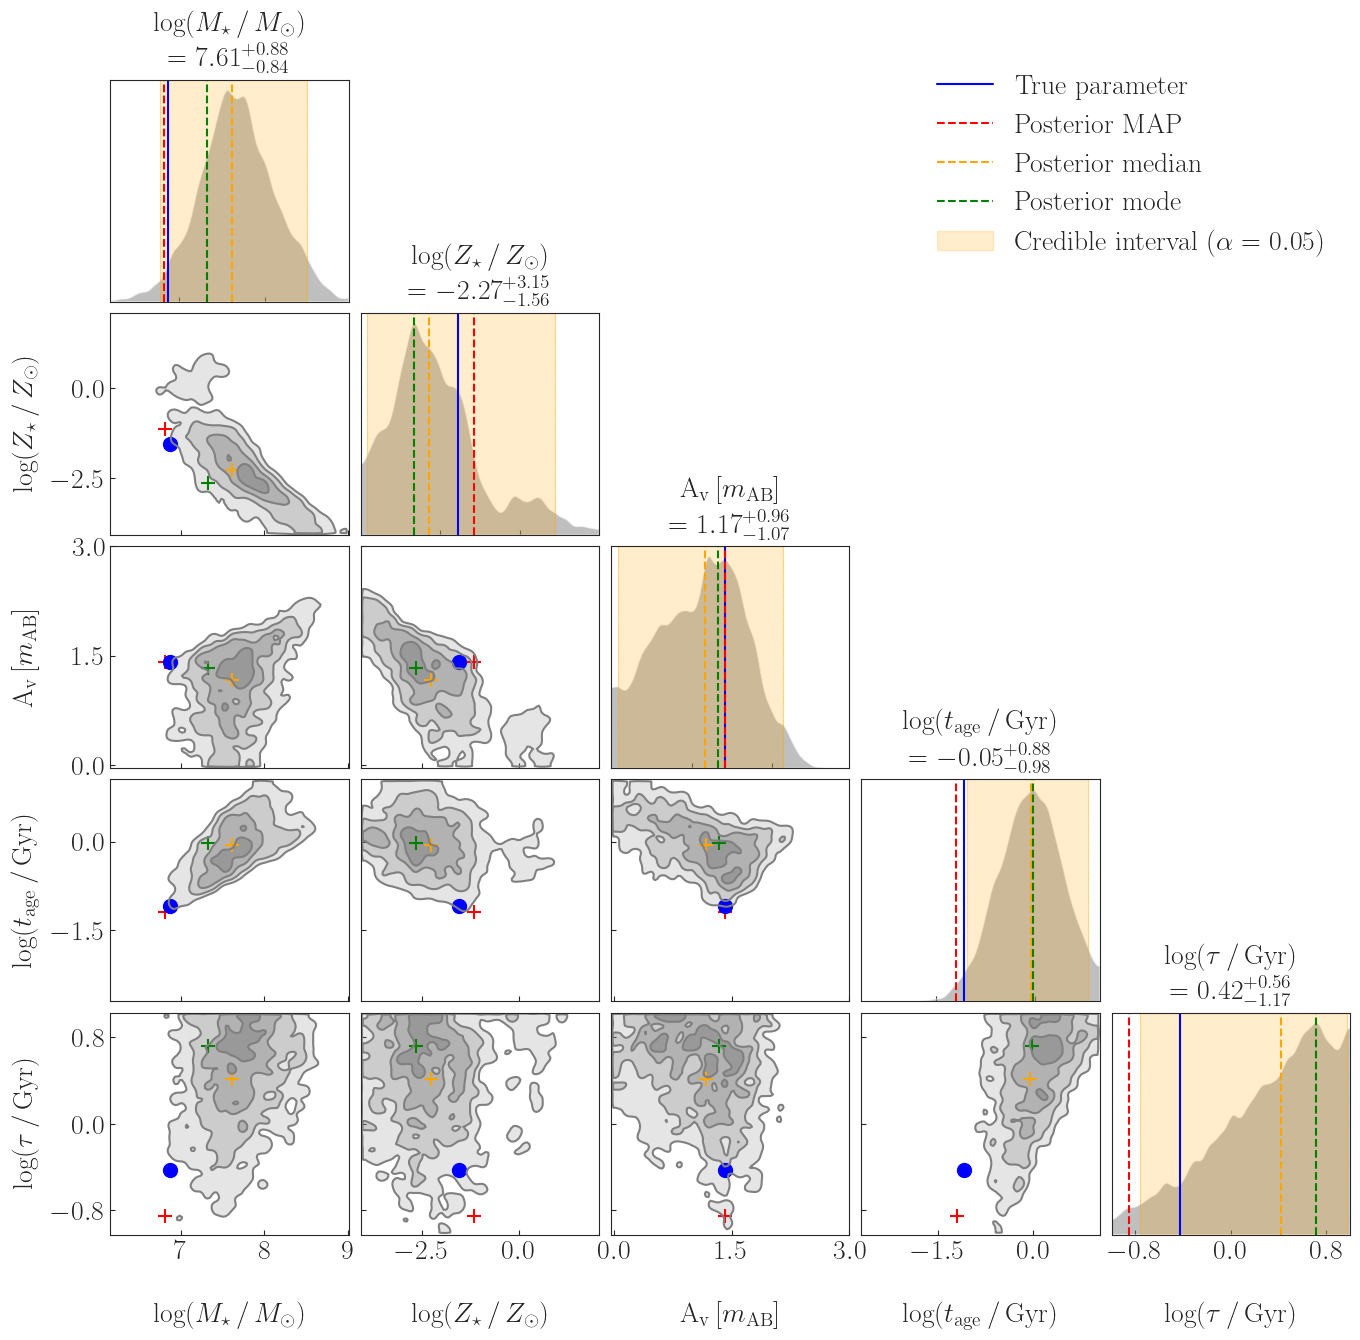

In [30]:
nsamples, ndim = result['chain'].shape
samples = result['chain'].T
weights = result['weights']

_labels = result['theta_labels']
logify_labels = ['mass', 'tage', 'tau']

# column pre- and suffixes for best fit parameters
# change accordingly

# mode
best_fit_param_suffix3 = '_mode'
best_fit_param_cr_prefix3 = '_md'
legend_label3 = 'mode'

# median
best_fit_param_suffix2 = '_median'
best_fit_param_cr_prefix2 = '_se'
legend_label2 = 'median'

# MAP
best_fit_param_suffix = '_MAP'
best_fit_param_cr_prefix = '_cr'
legend_label = 'MAP'

cols = ['peak_'+label for label in _labels]
true_values = _df.iloc[0][cols]

# logify some parameters
samples_adjusted = samples.copy()

cols_best = []
cols_map_cr_lower = []
cols_map_cr_upper = []

cols_best2 = []
cols_map_cr_lower2 = []
cols_map_cr_upper2 = []

cols_best3 = []
cols_map_cr_lower3 = []
cols_map_cr_upper3 = []

# logify
for idx, label in enumerate(_labels):
    if label in logify_labels:
        samples_adjusted[idx,:] = np.log10(samples_adjusted[idx,:])
        true_values['peak_'+label] = np.log10(true_values['peak_'+label])

        cols_best.append('l' + label + best_fit_param_suffix)
        cols_map_cr_lower.append('l' + label + best_fit_param_cr_prefix + '_lower')
        cols_map_cr_upper.append('l' + label + best_fit_param_cr_prefix + '_upper')
        cols_best2.append('l' + label + best_fit_param_suffix2)
        cols_map_cr_lower2.append('l' + label + best_fit_param_cr_prefix2 + '_lower')
        cols_map_cr_upper2.append('l' + label + best_fit_param_cr_prefix2 + '_upper')
        cols_best3.append('l' + label + best_fit_param_suffix3)
        cols_map_cr_lower3.append('l' + label + best_fit_param_cr_prefix3 + '_lower')
        cols_map_cr_upper3.append('l' + label + best_fit_param_cr_prefix3 + '_upper')
    else:
        cols_best.append(label + best_fit_param_suffix)
        cols_map_cr_lower.append(label + best_fit_param_cr_prefix + '_lower')
        cols_map_cr_upper.append(label + best_fit_param_cr_prefix + '_upper')
        cols_best2.append(label + best_fit_param_suffix2)
        cols_map_cr_lower2.append(label + best_fit_param_cr_prefix2 + '_lower')
        cols_map_cr_upper2.append(label + best_fit_param_cr_prefix2 + '_upper')
        cols_best3.append(label + best_fit_param_suffix3)
        cols_map_cr_lower3.append(label + best_fit_param_cr_prefix3 + '_lower')
        cols_map_cr_upper3.append(label + best_fit_param_cr_prefix3 + '_upper')

pbest = np.array(_df.iloc[0][cols_best].to_numpy(dtype=float))
pbest2 = np.array(_df.iloc[0][cols_best2].to_numpy(dtype=float))
pbest3 = np.array(_df.iloc[0][cols_best3].to_numpy(dtype=float))
# pbest = best_sample(result)
map_cred_int_lower = _df.iloc[0][cols_map_cr_lower]
map_cred_int_upper = _df.iloc[0][cols_map_cr_upper]
map_cred_int_lower2 = _df.iloc[0][cols_map_cr_lower2]
map_cred_int_upper2 = _df.iloc[0][cols_map_cr_upper2]
map_cred_int_lower3 = _df.iloc[0][cols_map_cr_lower3]
map_cred_int_upper3 = _df.iloc[0][cols_map_cr_upper3]

if 'zred' in _labels:
    labels = [r'$z$', r'$\log(M_\star\,/\,M_\odot)$', r'$\log(Z_\star\,/\,Z_\odot)$', r'$\mathrm{A}_\mathrm{v}\, [m_{\mathrm{AB}}]$', 'Age [Gyr]', r'$\log(\tau\, / \mathrm{Gyr})$']
    # ax_sci_not = 1
else:
    # labels = [r'$\log(M_\star\,/\,M_\odot)$', r'$\log(Z_\star\,/\,Z_\odot)$', r'$\mathrm{A}_\mathrm{v}\, [m_{\mathrm{AB}}]$', 'Age [Gyr]', r'$\log(\tau\, / \mathrm{Gyr})$']
    labels = [r'$\log(M_\star\,/\,M_\odot)$', r'$\log(Z_\star\,/\,Z_\odot)$', r'$\mathrm{A}_\mathrm{v}\, [m_{\mathrm{AB}}]$', r'$\log(t_{\mathrm{age}}\,/\,\mathrm{Gyr})$', r'$\log(\tau\,/\,\mathrm{Gyr})$']

cfig, axes = plt.subplots(ndim, ndim, figsize=(16,15))
plt.subplots_adjust(hspace=.05, wspace=.05)

font_size = 20
colour = '#1f77b4'
# q_colour = 'grey'
hist_kwargs = {'alpha': 0.1}
hist2d_kwargs = {'alpha': 0.2}
label_kwargs={"fontsize": 20}
tick_kwargs={"labelsize": 20}

axes = corner.allcorner(
    samples=samples_adjusted, 
    labels=labels, 
    axes=axes, 
    weights=weights, 
    # color=colour, 
    # span=[(5, 9), (-4.0, 2.0), (0.0, 4.0), (0.0, 0.9), (-2, 2.0)],
    # qcolor=q_colour,
    show_titles=False,
    # hist_kwargs=hist_kwargs,
    hist2d_kwargs=hist2d_kwargs,
    label_kwargs=label_kwargs,
    tick_kwargs=tick_kwargs
)

ax_max = len(samples)-1
for i, xx in enumerate(samples):
    ax = axes[i, i]
    x = xx.flatten()
    qs = [pbest[i]-map_cred_int_lower.iloc[i], pbest[i], pbest[i]+map_cred_int_upper.iloc[i]]
    qs2 = [pbest2[i]-map_cred_int_lower2.iloc[i], pbest2[i], pbest2[i]+map_cred_int_upper2.iloc[i]]
    qs3 = [pbest3[i]-map_cred_int_lower3.iloc[i], pbest3[i], pbest3[i]+map_cred_int_upper3.iloc[i]]

    # ax.axvline(qs[0], lw=1.5, ls=':', color='red')
    # ax.axvline(qs[2], lw=1.5, ls=':', color='red')
    ax.axvline(qs2[0], lw=.5, ls=':', color='orange')
    ax.axvline(qs2[2], lw=.5, ls=':', color='orange')
    # ax.axvline(qs3[0], lw=1.5, ls=':', color='lightgreen')
    # ax.axvline(qs3[2], lw=1.5, ls=':', color='lightgreen')
    # credible_interval = ax.axvspan(qs[0], qs[2], alpha=0.2, color='red')
    credible_interval2 = ax.axvspan(qs2[0], qs2[2], alpha=0.2, color='orange')
    # credible_interval3 = ax.axvspan(qs3[0], qs3[2], alpha=0.2, color='green')

    true_line = ax.axvline(x=true_values.iloc[i], ls='-', lw=1.5, c='blue', label='True parameter')
    posterior_line = ax.axvline(x=pbest[i], ls='--', lw=1.5, c='red', label='Posterior MAP')
    posterior_line2 = ax.axvline(x=pbest2[i], ls='--', lw=1.5, c='orange', label='Posterior median')
    posterior_line3 = ax.axvline(x=pbest3[i], ls='--', lw=1.5, c='green', label='Posterior mode')

    title_fmt=".2f"
    fmt = "{{0:{0}}}".format(title_fmt).format
    title = r"${{{0}}}_{{-{1}}}^{{+{2}}}$"
    title = title.format(fmt(pbest2[i]), fmt(map_cred_int_lower2.iloc[i]), fmt(map_cred_int_upper2.iloc[i]))

    title = "{0}\n= {1}".format(labels[i], title)
    ax.set_title(title, fontsize=font_size, pad=10)

    axes[ax_max, i].xaxis.label.set_size(font_size)
    axes[ax_max, i].xaxis.set_tick_params(labelsize=font_size, rotation=0)
    axes[i, 0].yaxis.label.set_size(font_size)
    axes[i, 0].yaxis.set_tick_params(labelsize=font_size, rotation=0)

corner.scatter(pbest[:, None], axes, color='red', marker='+', s=100)
corner.scatter(pbest2[:, None], axes, color='orange', marker='+', s=100)
corner.scatter(pbest3[:, None], axes, color='green', marker='+', s=100)
corner.scatter(np.array([true_values.to_numpy(dtype=float)], None).T, axes, color='blue', marker='o', s=100)

cfig.legend(
    handles=[true_line, posterior_line, posterior_line2, posterior_line3, credible_interval2], 
    labels=['True parameter', 'Posterior {}'.format(legend_label), 'Posterior {}'.format(legend_label2), 'Posterior {}'.format(legend_label3), r'Credible interval ($\alpha=0.05$)'], 
    loc='upper right', 
    bbox_to_anchor=(.9, .9), 
    frameon=False, 
    fontsize=font_size
)

# plt.savefig('example_cornerplot.pdf', bbox_inches='tight')

In [12]:
sps = CSPSpecBasis(zcontinuous=1, compute_vega_mags=False)

In [13]:
def build_model(sfh='delayedTau', object_redshift=None, object_redshift_err=None, object_metallicity=None, object_metallicity_err=None, add_duste=False, add_neb=False, **kwargs):
    """
      Construct a model.
      This method defines a number of parameter specification dictionaries 
      and uses them to initialize a `models.sedmodel.SedModel` object.

      Args:
        sfh : (optional, default delayed-tau model) defines the applied SFH for the model, either 'delayedTau' or 'constant'
        object_redshift : (optional, default: None) if given, the model redshift is set to this value
        object_redshift_err : (optional, default: None) if an error range for redshift is given, the redshift will also be fit using the range as prior
        object_metallicity : (optional, default: None) - if given, the model logzsol is set to this value
        object_metallicity_err : (optional, default: None) if an error range for metallicity is given, the metallicity will also be fit using the range as prior
        add_dust : (optional, default: False) - Switch to add (fixed) parameters relevant for dust emission
        add_neb : (optional, default: False) - Switch to add (fixed) parameters relevant for nebular emission, and turn nebular emission on

      Returns:
        model: `models.sedmodel.SedModel` object
    """

    # --- Get a basic delay-tau SFH parameter set. ---
    model_params = TemplateLibrary['parametric_sfh']

    if sfh == 'constant':
        # params for constant SFH
        model_params['sfh'] = {'N': 1, 'isfree': False, 'init': 4}
        model_params['const'] = {'N': 1, 'isfree': False, 'init': 1.0} # Defines the constant component (fraction) of the SFH.
        model_params['fburst'] = {'N': 1, 'isfree': False, 'init': 0.0} # Defines the fraction of mass formed in an instantaneous burst of star formation.
        model_params['tau'] = {'N': 1, 'isfree': False, 'init': 1.0} # set fixed to 1.0
    else:
        # params for delayed-tau, leave other to default
        model_params['tau'] = {'N': 1, 'isfree': True, 'init': 1.0, 'prior': priors.LogUniform(mini=1e-1, maxi=10)}

    model_params['imf_type'] = {'N': 1, 'isfree': False, 'init': 1} # Chabrier (2003)
    model_params['dust_type'] = {'N': 1, 'isfree': False, 'init': 2}  # Calzetti et al. (2000)
    model_params['dust1'] = {'N': 1, 'isfree': False, 'init': 0.0}  # required for Calzetti

    model_params['dust2'] = {'N': 1, 'isfree': True, 'init': 0.6, 'prior': priors.TopHat(mini=0.0, maxi=6.0)}
    model_params['tage'] = {'N': 1, 'isfree': True, 'init': 0.3, 'prior': priors.TopHat(mini=0.001, maxi=10.0)}
    model_params['mass'] = {'N': 1, 'isfree': True, 'init': 1e6, 'prior': priors.LogUniform(mini=1e4, maxi=1e9)}

    # Change the model parameter specifications based on some keyword arguments
    if object_redshift is not None:
        model_params['zred'] = {'N': 1, 'isfree': False, 'init': object_redshift}

    if object_redshift is not None and object_redshift_err is not None:
        model_params['zred'] = {'N': 1, 'isfree': True, 'init': object_redshift, 'prior': priors.Normal(mean=object_redshift, sigma=object_redshift_err)}

    if object_metallicity is not None:
        model_params['logzsol'] = {'N': 1, 'isfree': False, 'init': object_metallicity}

    if object_metallicity is not None and object_metallicity_err is not None:
        model_params['logzsol'] = {'N': 1, 'isfree': True, 'init': object_metallicity, 'prior': priors.TopHat(mini=-4.0, maxi=2.0)}
        # model_params['logzsol'] = {'N': 1, 'isfree': True, 'init': object_metallicity, 'prior': priors.Normal(mean=object_metallicity, sigma=object_metallicity_err)}

    if add_duste:
        # Add dust emission (with fixed dust SED parameters)
        model_params.update(TemplateLibrary['dust_emission'])

    if add_neb:
        # Add nebular emission (with fixed parameters)
        model_params.update(TemplateLibrary['nebular'])

    # Now instantiate the model using this new dictionary of parameter specifications
    model = SedModel(model_params)

    return model

In [ ]:
object_redshift = _df.query('HSCobjid==@objid & clump_id==@clump_id & peak_id==@peak_id')['SDSS_redshift'].iloc[0]

model = build_model(
    sfh='delayedTau', 
    object_redshift=object_redshift, 
    object_redshift_err=None,
    object_metallicity=0.0, 
    object_metallicity_err=0.25, 
    add_duste=True, 
    add_neb=True
)

In [15]:
model

:::::::
<class 'prospect.models.sedmodel.SedModel'>

Free Parameters: (name: prior) 
-----------
  mass: <class 'prospect.models.priors.LogUniform'>(mini=10000.0,maxi=1000000000.0)
  logzsol: <class 'prospect.models.priors.TopHat'>(mini=-4.0,maxi=2.0)
  dust2: <class 'prospect.models.priors.TopHat'>(mini=0.0,maxi=6.0)
  tage: <class 'prospect.models.priors.TopHat'>(mini=0.001,maxi=10.0)
  tau: <class 'prospect.models.priors.LogUniform'>(mini=0.1,maxi=10)

Fixed Parameters: (name: value [, depends_on]) 
-----------
  zred: [0.09168439] 
  sfh: [4] 
  imf_type: [1] 
  dust_type: [2] 
  dust1: [0.] 
  add_dust_emission: [ True] 
  duste_umin: [1.] 
  duste_qpah: [4.] 
  duste_gamma: [0.001] 
  add_neb_emission: [ True] 
  add_neb_continuum: [ True] 
  nebemlineinspec: [ True] 
  gas_logz: [0.] <function stellar_logzsol at 0x30ffca2a0>
  gas_logu: [-2.] 

In [16]:
specarr = []
idx = np.random.randint(result['chain'].shape[0], size=500)
# result['chain'][np.random.choice(result['chain'].shape[0], 2, replace=False), :]

for theta in result['chain'][idx,:]:
    s = model.predict(theta, obs, sps=sps)[0]
    specarr.append(s)

post_pcts = quantile(np.array(specarr).T, [0.025, 0.5, 0.975], weights=result['weights'][idx])
# post_pcts = quantile(np.array(specarr).T, [0.16, 0.5, 0.84], weights=result['weights'][idx])

In [ ]:
_labels = result['theta_labels']

cols_best = [label+'_mode' for label in _labels]
theta = np.array(_df.iloc[0][cols_best].to_numpy(dtype=float))
test_model_mode = model.predict(theta, obs, sps=sps)

In [20]:
cols_best = [label+'_median' for label in _labels]
theta = np.array(_df.iloc[0][cols_best].to_numpy(dtype=float))
test_model_median = model.predict(theta, obs, sps=sps)

In [21]:
# true spectrum
cols = ['peak_mass', 'peak_logzsol', 'peak_dust2', 'peak_tage', 'peak_tau']
true_values = _df.query('HSCobjid==@objid & clump_id==@clump_id & peak_id==@peak_id')[cols].iloc[0]
theta_mock = np.array([true_values.to_numpy(dtype=float)], None).T
model_mock = model.predict(theta_mock, obs, sps=sps)

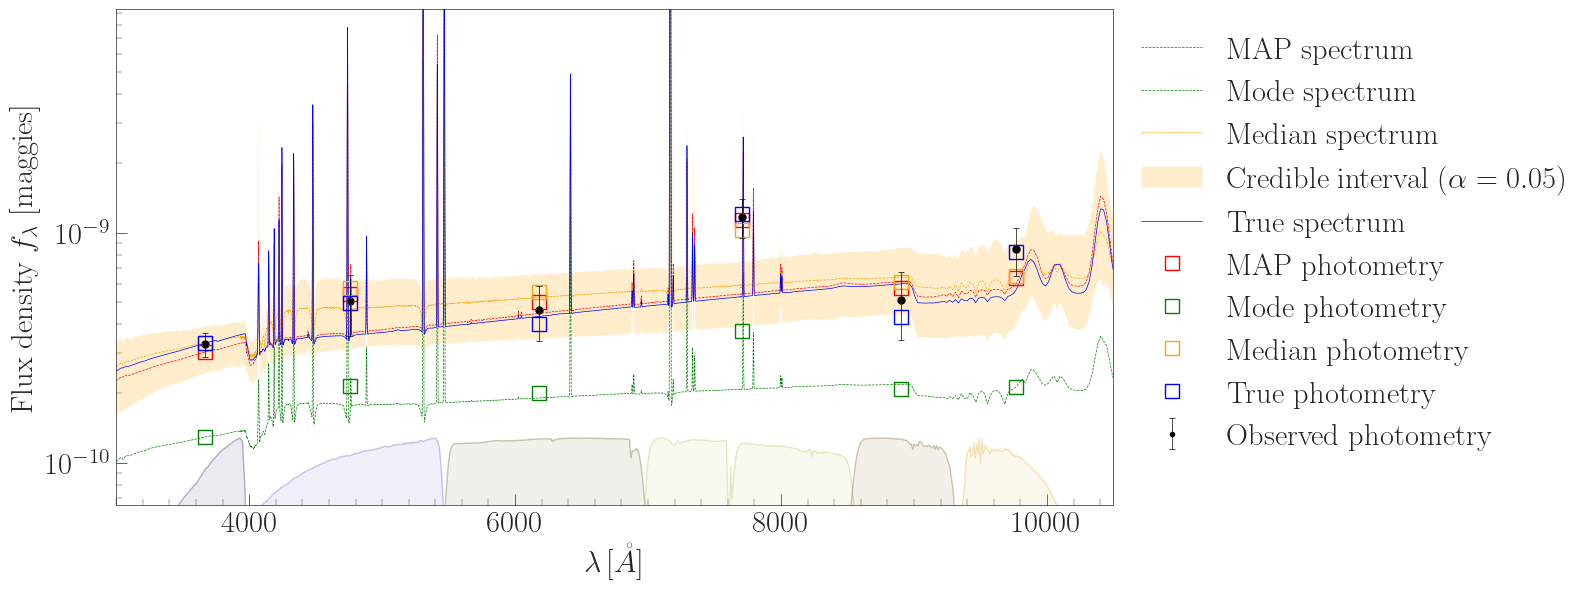

In [22]:
fig, ax = plt.subplots(figsize=(16,6))
font_size = 22

true_mags_list = _df.query('HSCobjid==@objid & clump_id==@clump_id & peak_id==@peak_id')[mag_cols_true].values.flatten().tolist()
sim_maggies = np.array([10**(-0.4 * mag) for mag in true_mags_list])

pwave = np.array([f.wave_effective for f in obs['filters']])

# plot the data
ax.plot(pwave, obs['maggies'], linestyle='', marker='o', color='k', ms=5)
ax.errorbar(pwave,  obs['maggies'], obs['maggies_unc'], linestyle='', color='k', fmt='.', ecolor='k', elinewidth=0.5, capsize=2, capthick=.5, zorder=10, label='Observed photometry')
ax.set_ylabel(r'Flux density $f_\lambda$ [maggies]', fontsize=font_size)
ax.set_xlabel(r'$\lambda\, [\mathring{A}]$', fontsize=font_size)
# ax.set_xlim(3e3, 1.1e4)
ax.set_xlim(3e3, 1.05e4)
# ax.set_ylim(sim_maggies.min()*0.5, obs['maggies'].max() * 5)
ax.set_ylim(obs['maggies'].min()*0.2, obs['maggies'].max()*8)
ax.set_yscale('log')

# get the best-fit SED
bsed = result['bestfit']
ax.plot(bsed['restframe_wavelengths'] * (1+obs['redshift']), bsed['spectrum'], color='red', ls='--', linewidth=0.5, label='MAP spectrum')
ax.plot(bsed['restframe_wavelengths'] * (1+obs['redshift']), test_model_mode[0], color='green', ls='--', linewidth=0.5, label='Mode spectrum')
ax.plot(bsed['restframe_wavelengths'] * (1+obs['redshift']), test_model_median[0], color='orange', ls='--', linewidth=0.5, label='Median spectrum')
ax.fill_between(bsed['restframe_wavelengths'] * (1+obs['redshift']), post_pcts[:, 0], post_pcts[:, -1], facecolor='orange', alpha=0.2, label=r'Credible interval ($\alpha=0.05$)')

ax.plot(bsed['restframe_wavelengths'] * (1+obs['redshift']), model_mock[0]*1.25, color='blue', ls='-', linewidth=0.5, label='True spectrum')

# Plot photometry
ax.plot(pwave, bsed['photometry'], linestyle='', marker='s', markersize=10, mec='red', mew=1, mfc='none', label='MAP photometry')
ax.plot(pwave, test_model_mode[1], linestyle='', marker='s', markersize=10, mec='green', mew=1, mfc='none', label='Mode photometry')
ax.plot(pwave, test_model_median[1], linestyle='', marker='s', markersize=10, mec='orange', mew=1, mfc='none', label='Median photometry')
ax.plot(pwave, sim_maggies, linestyle='', marker='s', markersize=10, mec='blue', mew=1, mfc='none', label='True photometry')

# plot transmission curves
xmin, xmax = obs['phot_wave'].min()*0.8, obs['phot_wave'].max()/0.8
ymin, ymax = obs['maggies'].min()*0.4, obs['maggies'].max()/10
for i, f in enumerate(obs['filters']):
    w, t = f.wavelength.copy(), f.transmission.copy()
    t = t / t.max()
    t = 10**(0.2*(np.log10(ymax/ymin)))*t * ymin
    ax.plot(w, t, lw=1, color=palette[i*2], alpha=0.3)
    ax.fill_between(w, t, 0, color=palette[i*2], alpha=0.1)

ax.tick_params('both', length=8, width=.5, which='major', labelsize=font_size)
ax.tick_params('both', length=4, width=.3, which='minor')
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2000.))
# ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2.))
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(200.))
# ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1.))

# ax.legend(loc='upper left', ncols=1, frameon=True, fontsize=font_size, ncol=2)
# ax.legend(loc='lower left', ncols=1, frameon=True, fontsize=font_size)
# ax.legend(loc='lower right', ncols=1, frameon=True, fontsize=font_size)
ax.legend(loc='upper left', ncols=1, frameon=False, bbox_to_anchor=(1., 1.), fontsize=font_size)

plt.setp(ax.spines.values(), linewidth=.5)
plt.tight_layout()
# plt.savefig('example_sed_spectrum.pdf', bbox_inches='tight')

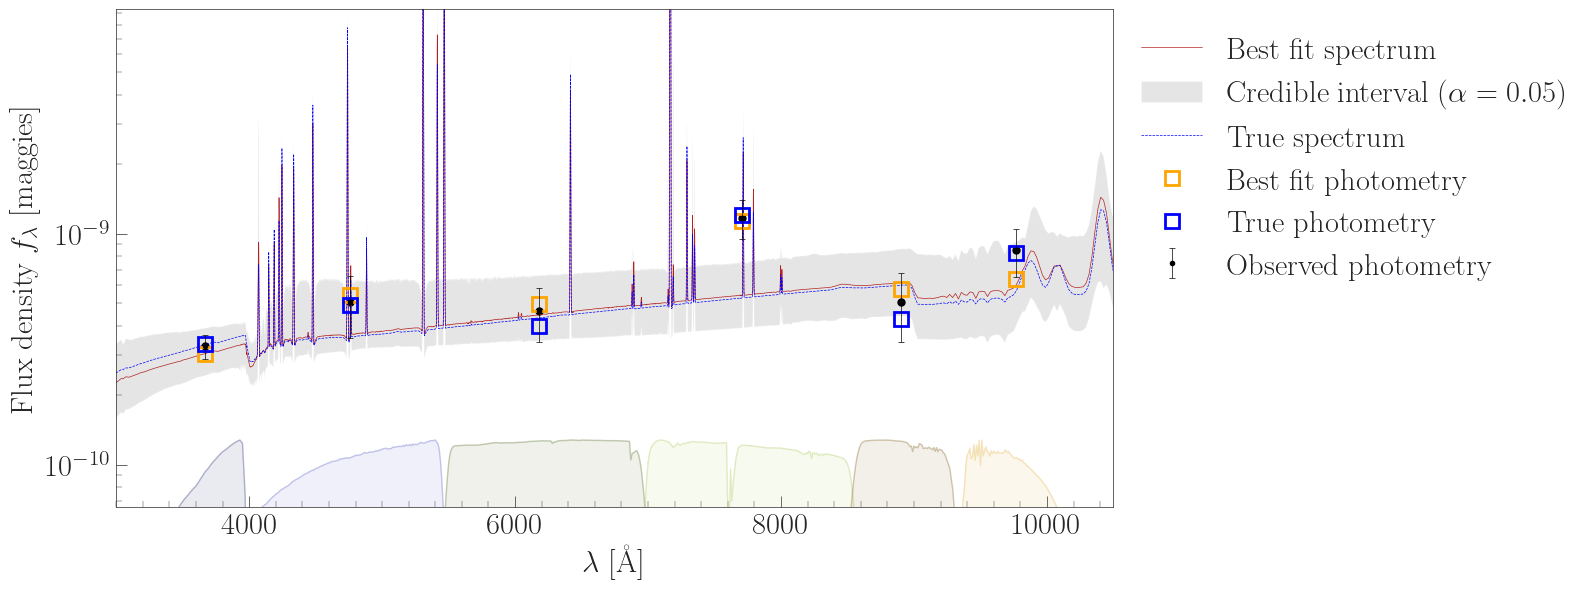

In [ ]:
fig, ax = plt.subplots(figsize=(16,6))
font_size = 22

true_mags_list = _df.query('HSCobjid==@objid & clump_id==@clump_id & peak_id==@peak_id')[mag_cols_true].values.flatten().tolist()
sim_maggies = np.array([10**(-0.4 * mag) for mag in true_mags_list])

pwave = np.array([f.wave_effective for f in obs['filters']])

# plot the data
ax.plot(pwave, obs['maggies'], linestyle='', marker='o', color='k', ms=5)
ax.errorbar(pwave,  obs['maggies'], obs['maggies_unc'], linestyle='', color='k', fmt='.', ecolor='k', elinewidth=0.5, capsize=2, capthick=.5, zorder=10, label='Observed photometry')
ax.set_ylabel(r'Flux density $f_\lambda$ [maggies]', fontsize=font_size)
ax.set_xlabel(r'$\lambda$ [\r{A}]', fontsize=font_size)
# ax.set_xlim(3e3, 1.1e4)
ax.set_xlim(3e3, 1.05e4)
# ax.set_ylim(sim_maggies.min()*0.5, obs['maggies'].max() * 5)
ax.set_ylim(obs['maggies'].min()*0.2, obs['maggies'].max()*8)
ax.set_yscale('log')

# get the best-fit SED
bsed = result['bestfit']
ax.plot(bsed['restframe_wavelengths'] * (1+obs['redshift']), bsed['spectrum'], color='firebrick', linewidth=0.5, label='Best fit spectrum')
# ax.plot(bsed['restframe_wavelengths'] * (1+obs['redshift']), test_model[0], color='green', linewidth=0.5, label='Mode spectrum')
# ax.plot(bsed['restframe_wavelengths'] * (1+obs['redshift']), test_model2[0], color='cyan', linewidth=0.5, label='Median spectrum')
ax.fill_between(bsed['restframe_wavelengths'] * (1+obs['redshift']), post_pcts[:, 0], post_pcts[:, -1], facecolor='grey', alpha=0.2, label=r'Credible interval ($\alpha=0.05$)')

ax.plot(bsed['restframe_wavelengths'] * (1+obs['redshift']), model_mock[0]*1.25, color='blue', ls='--', linewidth=0.5, label='True spectrum')

# Plot photometry
ax.plot(pwave, bsed['photometry'], linestyle='', marker='s', markersize=10, mec='orange', mew=2, mfc='none', label='Best fit photometry')
# ax.plot(pwave, test_model[1], linestyle='', marker='s', markersize=10, mec='green', mew=2, mfc='none', label='Mode photometry')
# ax.plot(pwave, test_model2[1], linestyle='', marker='s', markersize=10, mec='cyan', mew=2, mfc='none', label='Median photometry')
ax.plot(pwave, sim_maggies, linestyle='', marker='s', markersize=10, mec='blue', mew=2, mfc='none', label='True photometry')

# plot transmission curves
xmin, xmax = obs['phot_wave'].min()*0.8, obs['phot_wave'].max()/0.8
ymin, ymax = obs['maggies'].min()*0.4, obs['maggies'].max()/10
for i, f in enumerate(obs['filters']):
    w, t = f.wavelength.copy(), f.transmission.copy()
    t = t / t.max()
    t = 10**(0.2*(np.log10(ymax/ymin)))*t * ymin
    ax.plot(w, t, lw=1, color=palette[i*2], alpha=0.3)
    ax.fill_between(w, t, 0, color=palette[i*2], alpha=0.1)

ax.tick_params('both', length=8, width=.5, which='major', labelsize=font_size)
ax.tick_params('both', length=4, width=.3, which='minor')
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2000.))
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(200.))

ax.legend(loc='upper left', ncols=1, frameon=False, bbox_to_anchor=(1., 1.), fontsize=font_size)

plt.setp(ax.spines.values(), linewidth=.5)
plt.tight_layout()
# plt.savefig('sim_sed_spec_{}_{}_{}.pdf'.format(objid, clump_id, peak_id), bbox_inches='tight')